In [2]:
#!/usr/bin/env python3
"""Overlay the 2-term QS metric f_C vs rho for scan60 (TR optimized) vs
scan62 (no TR baseline), evaluated directly from each run's final.h5.

Aggregation: max|f_C| over (theta, zeta) at each rho (not DESC's default
flux-surface average -- see desc.plotting.plot_qs_error for that variant).

Normalization: DESC's own B0 convention from plot_qs_error, i.e. a true
flux-surface/volume averaged field strength

    B0 = mean(|B| * sqrt(g)) / mean(sqrt(g))

(NOT compute_scaling_factors()["B"], and NOT divided by psi_r -- no ad-hoc
normalization).

Run from the project root with the `desc` conda env:
    conda activate desc
    python combined_figures/plot_fC_overlay.py
"""
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from desc.equilibrium import Equilibrium
from desc.grid import LinearGrid

In [3]:
FontSize = 22
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
        "figure.figsize": (6.4, 4.8)
    }
)


# Default axes box in figure coordinates (0–1); tune once, reuse everywhere
AXES_MARGINS = dict(left=0.20, right=0.98, bottom=0.14, top=0.96) # percentages of the figure height/width

plt.rcParams.update(
    {
        "figure.subplot.left": AXES_MARGINS["left"],
        "figure.subplot.right": AXES_MARGINS["right"],
        "figure.subplot.bottom": AXES_MARGINS["bottom"],
        "figure.subplot.top": AXES_MARGINS["top"],
        # optional: spacing for multi-panel figures
        "figure.subplot.wspace": 0.25,
        "figure.subplot.hspace": 0.25,
    }
)


# apply to figures to apply even if using tight_layout
def apply_standard_axes(fig):
    fig.subplots_adjust(**AXES_MARGINS)

With $\Delta_{\rm res}$ ../scan60/final.h5 #1f77b4
With $\Delta_{\rm res}$: B0=5.2197 T  edge max|f_C|/B0^3=5.6457e-02  core max|f_C|/B0^3=1.0807e-02
Without $\Delta_{\rm res}$ ../scan62/final.h5 #d62728
Without $\Delta_{\rm res}$: B0=5.3088 T  edge max|f_C|/B0^3=8.3459e-02  core max|f_C|/B0^3=6.2939e-03
Wrote forpaper/fC_max_desc_norm_vs_rho_overlay.pdf


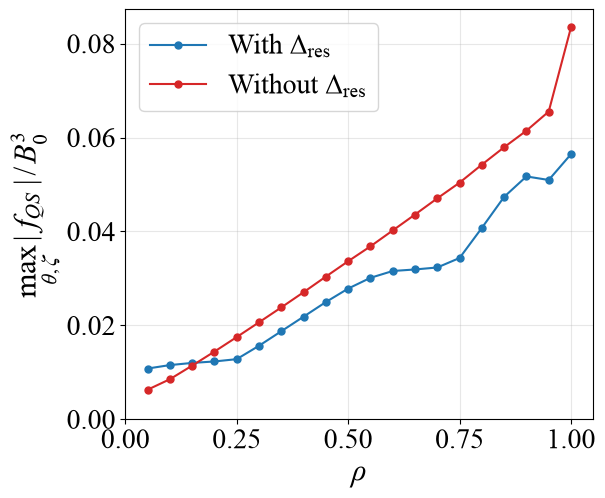

In [5]:
RUNS = [
    (r"With $\Delta_{\rm res}$", "../scan60/final.h5", "#1f77b4"),
    (r"Without $\Delta_{\rm res}$", "../scan62/final.h5", "#d62728"),
]

HELICITY = (1, 0)
RHO = np.linspace(0.05, 1.0, 20)

fig, ax = plt.subplots(figsize=(6, 5))

for label, path, color in RUNS:
    print(label, path, color)
    eq = Equilibrium.load(path)

    # DESC's own B0 convention (desc.plotting.plot_qs_error), not
    # compute_scaling_factors()["B"].
    data0 = eq.compute(["R0", "|B|"])
    B0 = np.mean(data0["|B|"] * data0["sqrt(g)"]) / np.mean(data0["sqrt(g)"])

    grid = LinearGrid(M=2 * eq.M_grid, N=2 * eq.N_grid, NFP=eq.NFP, rho=RHO)
    data = eq.compute(["f_C"], grid=grid, helicity=HELICITY)
    f_C = grid.meshgrid_reshape(data["f_C"], "rtz")
    fC_max = np.max(np.abs(f_C), axis=(1, 2)) / B0**3

    ax.plot(RHO, fC_max, "o-", color=color, label=label, markersize=5, linewidth=1.5)
    print(f"{label}: B0={B0:.4f} T  edge max|f_C|/B0^3={fC_max[-1]:.4e}  "
          f"core max|f_C|/B0^3={fC_max[0]:.4e}")

ax.set_xlabel(r"$\rho$", **label_kw)
ax.set_ylabel(r"$\max_{\theta,\zeta}|~f_{QS}~| \,/\, B_0^3$", **label_kw)
# ax.set_title(r"2-term QS metric $f_C$ vs $\rho$ (max over surface, DESC $B_0^3$ norm.)")
ax.set_xlim(0, 1.05)
ax.set_ylim(bottom=0)
ax.legend(loc="upper left", fontsize=tick_labelsize)
ax.grid(True, alpha=0.3)
ax.tick_params(axis="both", labelsize=tick_labelsize)
# fig.tight_layout()
apply_standard_axes(fig)

out = "forpaper/fC_max_desc_norm_vs_rho_overlay.pdf"
fig.savefig(out, dpi=300)
print(f"Wrote {out}")
